# Differential Abundance Analysis

With this analysis we want to  test whether individual ASVs/taxa differ in abundance between samples' groups - the type analysis known as differential abundance. We will use ANCOM-BC (analysis of composition of microbiomes with bias correction): a compositionally aware alternative that allows to test for differentially abundant features.

## Setup

In [ ]:
import os
import matplotlib.pyplot as plt
import pandas as pd
import qiime2 as q2
from qiime2 import Visualization
import seaborn as sns
from scipy.stats import shapiro, kruskal, f_oneway


data_dir = 'updog_data' 
    
%matplotlib inline

In [ ]:
!wget -O "$data_dir/mags-table-filtered-milo-no-unassigned.qza" "https://polybox.ethz.ch/index.php/s/88arfy68xK7Ydz7/download"

In [ ]:
!wget -O "$data_dir/kraken2-mags-taxonomy_db16_milo.qza" "https://polybox.ethz.ch/index.php/s/xaDScTmkMb95fkC/download"

In [ ]:
!wget -O "$data_dir/updog_metadata.tsv" "https://polybox.ethz.ch/index.php/s/pna5PZy62SfGcq5/download"

In [ ]:
!wget -O "$data_dir/updog-feature-table.qza" "https://polybox.ethz.ch/index.php/s/3NwEzFbbXSxZYxX/download"

## 1. Data Exploration

In [3]:
data = q2.Artifact.load(f'{data_dir}/updog-feature-table.qza').view(pd.DataFrame)
data.head()

/opt/conda/lib/python3.10/site-packages/unifrac/__init__.py:9: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


,0024a950-f4ad-4c18-a733-2050ee75184d,00290f32-cf20-4f2c-ae3b-160c75e28ea9,0032a0b3-ea8e-4024-a0a6-d873887f8a44,003b7e1f-f277-4c16-80a1-b4e02ca7fa7f,005525d2-7aa9-436f-a536-1c4234e782a7,006c42e8-3e46-40c7-b53c-60b810c7ddac,007b3451-6bc6-4fee-a716-6001b43e74f0,007e8510-72ae-4837-a4f6-2152c303bf25,0080aa29-a268-471f-b29e-f6f8128e0a62,008ac5de-ff0c-48ea-a8b1-de1a81df476b,...,ff889a3b-b97c-4516-8cbd-a7df6605d7ef,ff962d0d-5fb3-44c4-b100-aed40c1a32dd,ff98cd34-c9c9-4de2-b82f-f50c03832377,ff9adcce-7c67-40a4-9e94-2aa0777c1e36,ff9f75a3-89e5-4f60-a27f-8dd030fac145,ffaab7a6-a7ad-494c-828b-4d58e4ed1bf4,ffd2a7b5-d075-4929-a6db-485299996f7f,ffd4cbf5-7b3f-4480-9ed1-4dd18c1a7734,ffd4f8ae-1325-41ee-84fb-bdd74412ab73,ffdfd3f1-e9f7-4ee1-9eef-59ed0a1b6620
ERR2619707,103.807271,2.290796,42.427880,471.058609,278.755176,50.172306,4.782074,24.356805,76.227836,3.041216,...,15.786674,32.890911,95.119144,0.624413,1.258749,356.361348,13.000133,8.845186,14.463506,15.688009
ERR2619708,83.598821,1.819477,410.342125,32.328933,42.770201,1112.652408,0.520938,60.294359,264.622653,1.264152,...,11.483930,168.117865,69.411486,0.331138,9.300863,193.380497,97.994014,278.772887,5643.618098,6.238385
ERR2619709,13.909087,36.636840,184.686526,60.912226,576.560418,1984.583817,131.420285,40.621447,43.282710,27.243514,...,19.964331,16.142701,116.051221,1.390558,8.250856,142.221806,21.044646,16.292433,34.042237,32.766847
ERR2619710,45.196743,2.443732,1635.840021,4.084571,63.425400,488.083554,97.694643,145.360794,94.405494,1.549287,...,19.479813,79.545720,23.925300,0.764782,103.480336,733.154244,137.195781,74.394614,144.106067,21.736056
ERR2619711,31.410491,93.501377,278.755282,26.766809,52.347515,823.324965,100.272753,25.594041,49.372404,4.083253,...,0.520604,272.597092,198.569217,0.712811,6.747610,155.676908,251.473786,27.934501,39.738718,118.051000


## 1.1 Histogram
Looking at top three most abundant feature IDs

/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


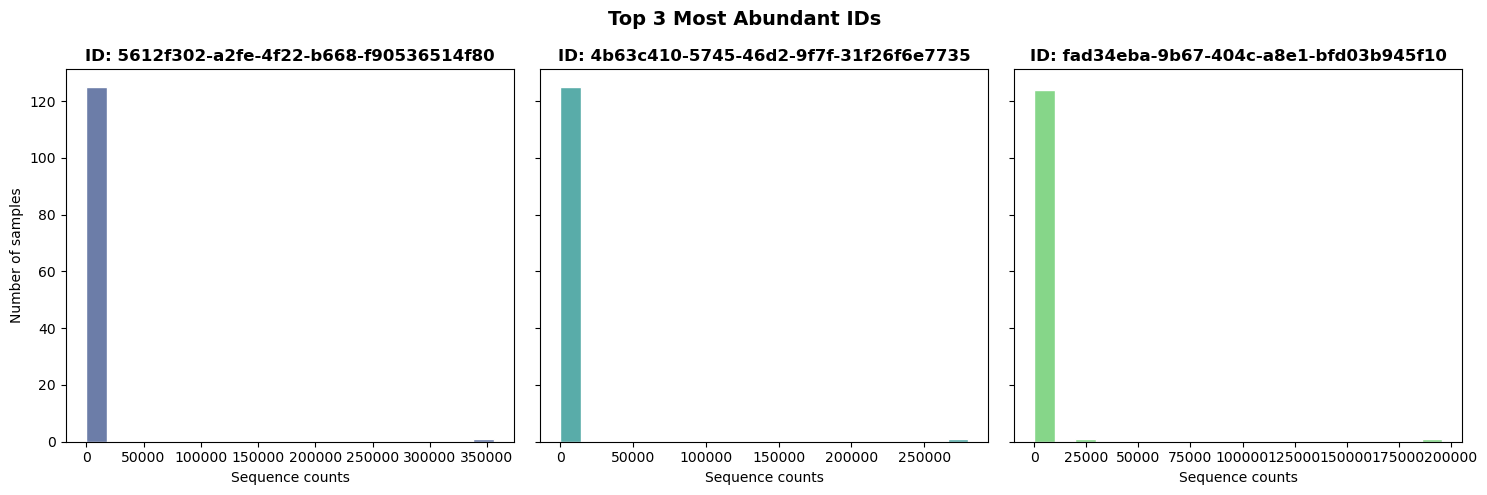

In [5]:
# Step 1: compute top 3 Feature IDs
asv_sums = data.sum(axis=0)
top3_asvs = asv_sums.sort_values(ascending=False).head(3).index
top_three = data[top3_asvs]

# Step 2: pick 3 distinct colors from the viridis palette
colors = sns.color_palette("viridis", n_colors=3)

# Step 3: plot individual histograms
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)

for ax, asv, color in zip(axes, top3_asvs, colors):
    sns.histplot(
        data=top_three[asv],
        bins=20,
        color=color,
        edgecolor='white',
        ax=ax
    )
    ax.set_title(f"ID: {asv}", fontsize=12, weight='bold')
    ax.set_xlabel("Sequence counts")
    ax.set_ylabel("Number of samples")

plt.suptitle("Top 3 Most Abundant IDs", fontsize=14, weight='bold')
plt.tight_layout()
plt.show()

## 1.2 Violin Plot
We need to create a new DataFrame with three columns: sample name, ASV ID and ASV abundance. We will also pick 15 samples out of the original DataFrame, to make the plot a little bit clearer.

In [11]:
n = 15

# draw n ASVs out of the original DataFrame
data_samp = data.sample(n=n, axis=1, random_state=234)

# create a new DataFrame with three columns (sample, ASV, abundance)
col_names = {'level_0': 'sample', 'level_1': 'asv', 0: 'count'}
data_plot = data_samp.stack().reset_index().rename(columns=col_names)

# make sure the shape is correct (no. of rows should be equal to the size of our random 
# sample multiplied by number of samples)
assert data_plot.shape[0] == n * data_samp.shape[0], 'The new DataFrame has an incorrect no. of rows.'

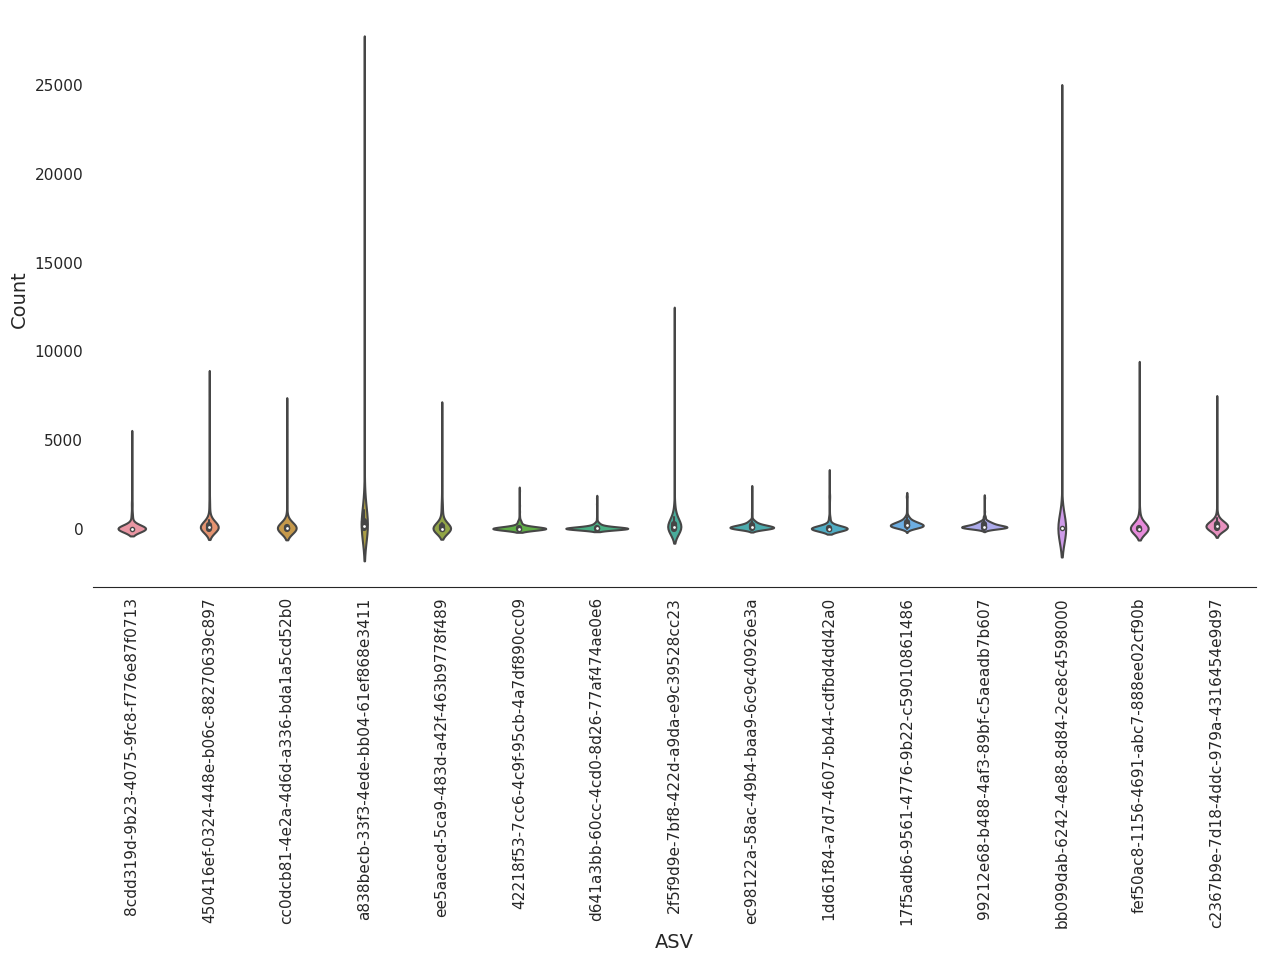

In [12]:
with sns.axes_style('white'), sns.color_palette('viridis'):
    fig, ax = plt.subplots()
    fig.set_size_inches(15, 7.5)
    
    sns.violinplot(data=data_plot, x='asv', y='count', ax=ax)
    sns.despine(left=True)
    
    # adjust tick labels and axes titles
    ax.tick_params(axis='x', rotation=90, labelsize=11)
    ax.tick_params(axis='y', labelsize=11)
    ax.set_xlabel('ASV', fontsize=14)
    ax.set_ylabel('Count', fontsize=14)

##  1.3 Shapiro-Wilk test for normality
The majority of values are focused around 0, with only some values being different. To get a more quantitative view of all the ASVs, we can additionally perform a statistical test for data normality. 

In [13]:
alpha = 0.05
results = {}

# iterate through rows (samples) and test each of them for normality
for asv_name, asv_values in data.items():
    stat, p = shapiro(asv_values)
    results[asv_name] = p

# convert test results into a DataFrame
results_df = pd.DataFrame(data=results.values(), index=results.keys(), columns=['p'])

# add a new column with a descriptive test result
results_df['is_normal'] = results_df['p'] > alpha

In [ ]:
results_df

To check whether there is any ASV that does have normal distribution, we sum all the values from the is_normal column: True values are equivalent to 1 and False values to 0 so if the sum is bigger than 0, then we have some ASVs that are distributed normally:

In [15]:
print('Number of ASVs with normal distribution:', results_df['is_normal'].sum())

Number of ASVs with normal distribution: 0


## 2. ANCOM with Taxa

We filter our feature table and only retain features that are present at some minimal frequency (25) and in at least 4 samples. This can improve resolution and limit FDR (false discovery rate) penalty on features that are too far below the noise threshhold to be applicable to a statistical test.

Let's try to see what happens when we collapse the taxa down to the genus level. We can do the using the collapse action from the taxa plugin:

## 2.1 Our Taxonomy File:

In [8]:
! qiime taxa collapse \
    --i-table $data_dir/mags-table-filtered-milo-no-unassigned.qza \
    --i-taxonomy $data_dir/kraken2-mags-taxonomy_db16_milo.qza \
    --p-level 6 \
    --o-collapsed-table $data_dir/table_abund_l6.qza

/opt/conda/lib/python3.10/site-packages/unifrac/__init__.py:9: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
Saved FeatureTable[Frequency] to: /home/jovyan/Group_Project/UpDoG/table_abund_l6.qza


We want to first find taxa differentially abundant in between samples. For this purpose, we can filter the feature table to only contain samples from these two environments as follows:

## 2.2 Farmer - Western

In [7]:
! qiime feature-table filter-samples \
    --i-table $data_dir/table_abund_l6.qza \
    --m-metadata-file $data_dir/updog_metadata.tsv \
    --p-where "[subsistence_mode]='Farmer' or [subsistence_mode]='Western'" \
    --o-filtered-table $data_dir/table_abund_FarmWest_l6.qza

/opt/conda/lib/python3.10/site-packages/unifrac/__init__.py:9: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
Saved FeatureTable[Frequency] to: /home/jovyan/Group_Project/UpDoG/table_abund_Far_West_l6.qza


Let's try to investigate the differential abundance across different **env**ironments:

In [6]:
# Run ANCOM-BC
! qiime composition ancombc \
    --i-table $data_dir/table_abund_FarmWest_l6.qza \
    --m-metadata-file $data_dir/updog_metadata.tsv \
    --p-formula subsistence_mode \
    --o-differentials $data_dir/ancombc_FarmWest_differentials.qza #FarmWest!!

# Generate a barplot of differentially abundant taxa between environments
! qiime composition da-barplot \
    --i-data $data_dir/ancombc_FarmWest_differentials.qza \
    --o-visualization $data_dir/ancombc_results/ancombc_FarmWest_da_barplot.qzv

# Generate a table of these same values for all taxa
! qiime composition tabulate \
    --i-data $data_dir/ancombc_FarmWest_differentials.qza \
    --o-visualization $data_dir/ancombc_results/ancombc_FarmWest_results.qzv

/opt/conda/lib/python3.10/site-packages/unifrac/__init__.py:9: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
Saved Visualization to: /home/jovyan/Group_Project/UpDoG/ancombc_FarmWest_results.qzv


In [3]:
Visualization.load(f"{data_dir}/ancombc_results/ancombc_FarmWest_da_barplot.qzv")

<visualization: Visualization uuid: d5cb51a4-0598-4a92-9eb4-37bba06bb2c4>

In [4]:
Visualization.load(f"{data_dir}/ancombc_results/ancombc_FarmWest_results.qzv")

<visualization: Visualization uuid: 02ab2297-8d00-42dc-9986-c17af741cf04>

### 2.2.1 Generating Heatmap FarmWest

/opt/conda/lib/python3.10/site-packages/unifrac/__init__.py:9: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
Exported /home/jovyan/Group_Project/UpDoG/ancombc_FarmWest_differentials.qza as DataLoafPackageDirFmt to directory exported_ancombc_FarmWest
LFC columns: Index(['(Intercept)', 'subsistence_modeWestern'], dtype='object')
p-value columns: Index(['(Intercept)', 'subsistence_modeWestern'], dtype='object')
Significant features: 48


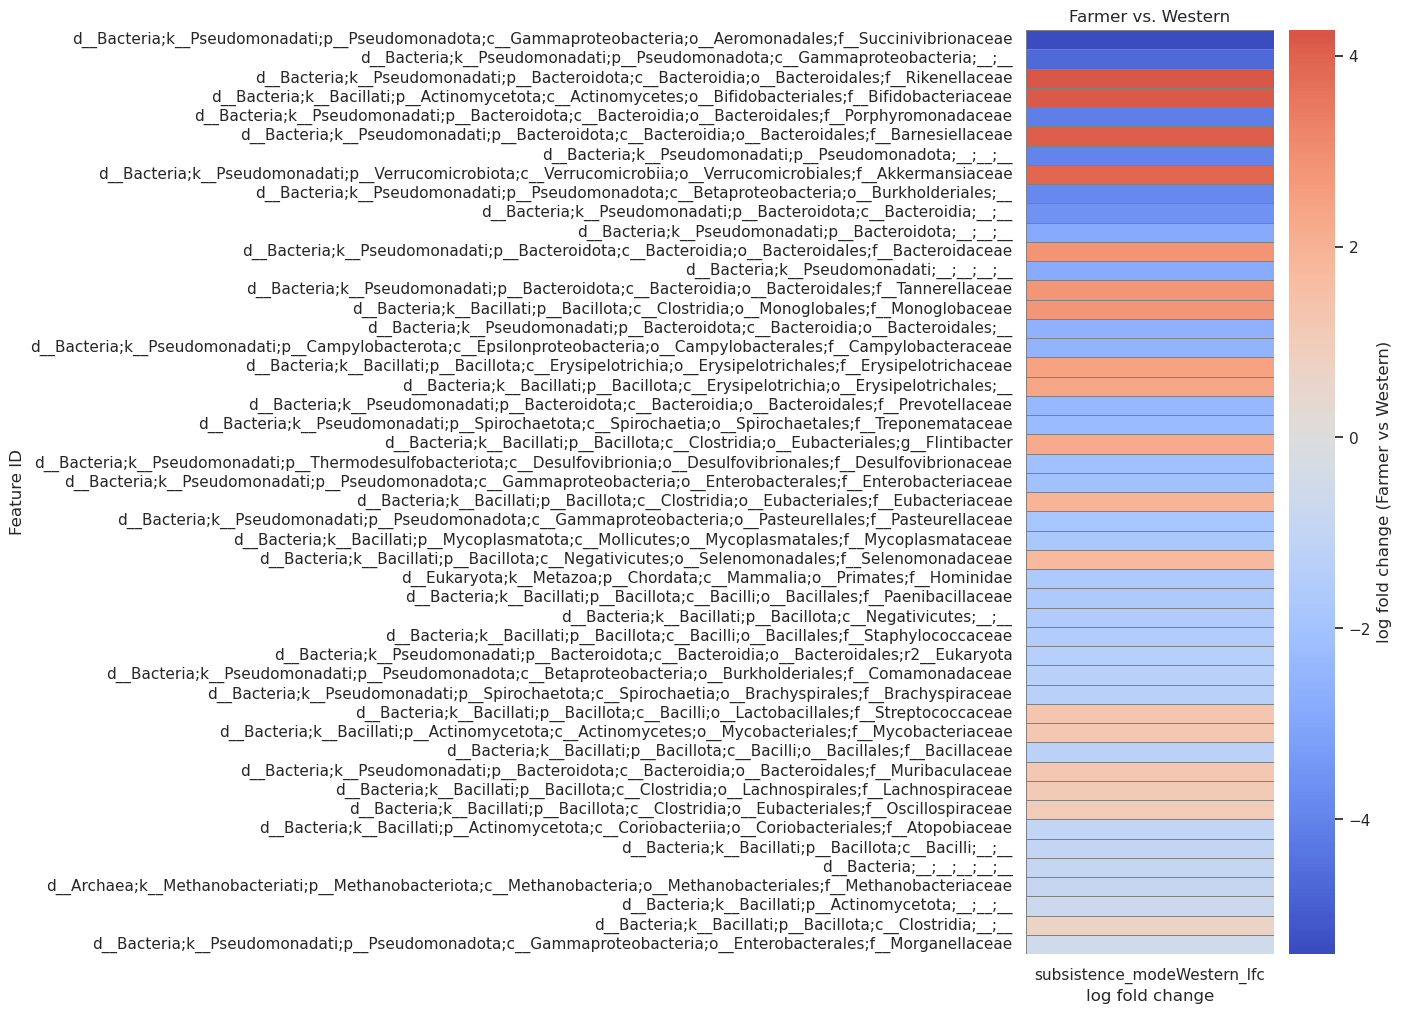

In [11]:
# --- 1. export ANCOM BC differentials to .tsv --- 

!qiime tools export \
    --input-path $data_dir/ancombc_FarmWest_differentials.qza \
    --output-path exported_ancombc_FarmWest

# --- 2. Load and merge the ANCOM-BC outputs ---

# Path to your exported ANCOM-BC results
base = "exported_ancombc_FarmWest"

# Load LFCs and p-values (adjust sep= if needed)
lfc = pd.read_csv(f"{base}/lfc_slice.csv", index_col=0)
pval = pd.read_csv(f"{base}/p_val_slice.csv", index_col=0)

print("LFC columns:", lfc.columns)
print("p-value columns:", pval.columns)

# --- 3. Merge into single DataFrame ---

df = lfc.join(pval, lsuffix="_lfc", rsuffix="_p")
df.head()

# --- 4. Filter to significant features only ---

lfc_col = "subsistence_modeWestern_lfc"
pval_col = "subsistence_modeWestern_p"

alpha = 0.05   # significance threshold

sig = df[df[pval_col] < alpha].copy()

print("Significant features:", sig.shape[0])
sig.head()

# --- 5. Sort values (optional) ---

lfc_col = "subsistence_modeWestern_lfc"

# sort features by LFC (absolute value: strongest changes on top)
sig_sorted = sig.reindex(sig[lfc_col].abs().sort_values(ascending=False).index)

# optionally keep only top N (e.g. 50) for plotting
topN = 50
sig_plot = sig_sorted.head(topN)

# --- 6. Build Matrix for Heat Map ---

heat_data_FarmWest = sig_plot[[lfc_col]]
heat_data_FarmWest.head()

# --- 7. Generate HeatMap ---

sns.set(style="white")

plt.figure(figsize=(4, max(4, 0.25 * heat_data_FarmWest.shape[0])))  # height scales with number of features

ax = sns.heatmap(
    heat_data_FarmWest,
    cmap="PRGn",                   
    center=0,                           
    cbar_kws={"label": "log fold change (Farmer vs Western)"},
    linewidths=0.5,
    linecolor="grey"
)

ax.set_xlabel("log fold change")
ax.set_ylabel("Feature ID")
ax.set_title("Farmer vs. Western")

plt.show()

## 2.3 Farmer - Fisher

In [17]:
! qiime feature-table filter-samples \
    --i-table $data_dir/table_abund_l6.qza \
    --m-metadata-file $data_dir/updog_metadata.tsv \
    --p-where "[subsistence_mode]='Farmer' or [subsistence_mode]='Fisher'" \
    --o-filtered-table $data_dir/table_abund_FarmFish_l6.qza

/opt/conda/lib/python3.10/site-packages/unifrac/__init__.py:9: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
Saved FeatureTable[Frequency] to: /home/jovyan/Group_Project/UpDoG/table_abund_FarmFish_l6.qza


In [20]:
# Run ANCOM-BC
! qiime composition ancombc \
    --i-table $data_dir/table_abund_FarmFish_l6.qza \
    --m-metadata-file $data_dir/updog_metadata.tsv \
    --p-formula subsistence_mode \
    --o-differentials $data_dir/ancombc_FarmFish_differentials.qza

# Generate a barplot of differentially abundant taxa between environments
! qiime composition da-barplot \
    --i-data $data_dir/ancombc_FarmFish_differentials.qza \
    --o-visualization $data_dir/ancombc_results/ancombc_FarmFish_da_barplot.qzv

# Generate a table of these same values for all taxa
! qiime composition tabulate \
    --i-data $data_dir/ancombc_FarmFish_differentials.qza \
    --o-visualization $data_dir/ancombc_results/ancombc_FarmFish_results.qzv

/opt/conda/lib/python3.10/site-packages/unifrac/__init__.py:9: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
Saved FeatureData[DifferentialAbundance] to: /home/jovyan/Group_Project/UpDoG/ancombc_FarmFish_differentials.qza
/opt/conda/lib/python3.10/site-packages/unifrac/__init__.py:9: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
Saved Visualization to: /home/jovyan/Group_Project/UpDoG/ancombc_FarmFish_da_barplot.qzv
/opt/conda/lib/python3.10/site-packages/unifrac/__init__.py:9: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa

In [21]:
Visualization.load(f"{data_dir}/ancombc_results/ancombc_FarmFish_da_barplot.qzv")

<visualization: Visualization uuid: d97f6022-cf6a-4fc9-aedb-f17ad5ae6275>

In [22]:
Visualization.load(f"{data_dir}/ancombc_results/ancombc_FarmFish_results.qzv")

<visualization: Visualization uuid: 6fd87445-cefc-43a6-932d-79ac6c6641e4>

### 2.3.1 Generate HeatMap FarmFish

/opt/conda/lib/python3.10/site-packages/unifrac/__init__.py:9: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
Exported /home/jovyan/Group_Project/UpDoG/ancombc_FarmFish_differentials.qza as DataLoafPackageDirFmt to directory exported_ancombc_FarmFish
LFC columns: Index(['(Intercept)', 'subsistence_modeFisher'], dtype='object')
p-value columns: Index(['(Intercept)', 'subsistence_modeFisher'], dtype='object')
Significant features: 27


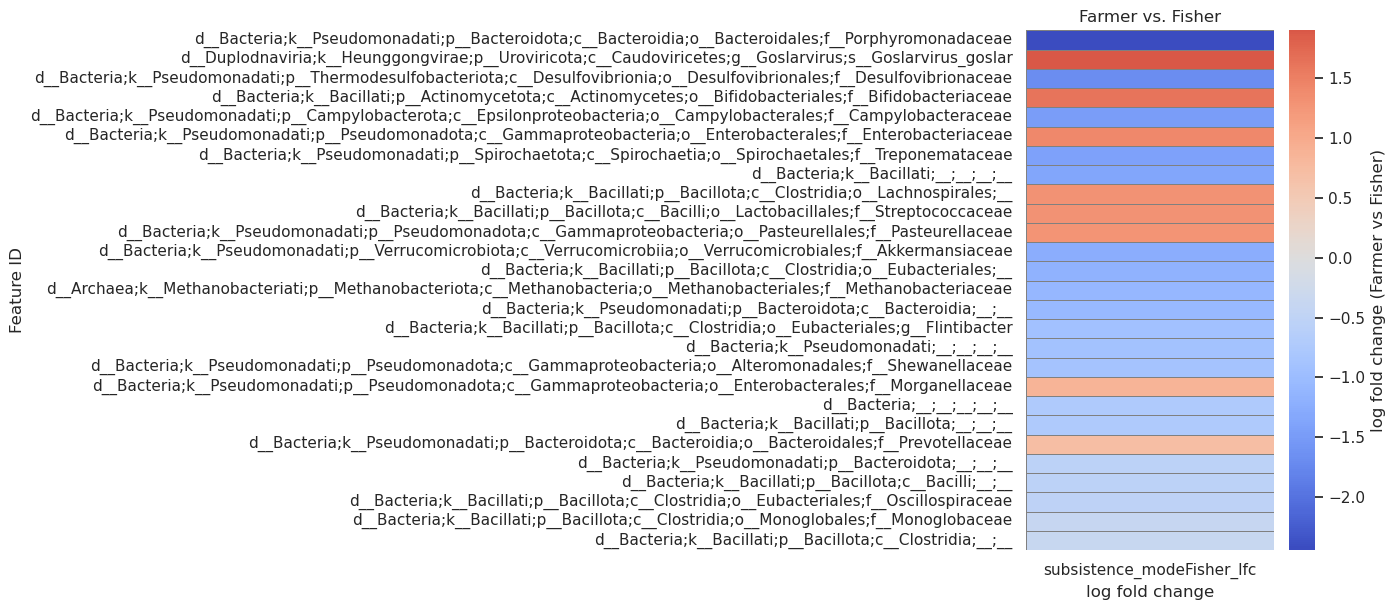

In [7]:
# --- 1. export ANCOM BC differentials to .tsv --- 

!qiime tools export \
    --input-path $data_dir/ancombc_FarmFish_differentials.qza \
    --output-path exported_ancombc_FarmFish

# --- 2. Load and merge the ANCOM-BC outputs ---

# Path to your exported ANCOM-BC results
base = "exported_ancombc_FarmFish"

# Load LFCs and p-values (adjust sep= if needed)
lfc = pd.read_csv(f"{base}/lfc_slice.csv", index_col=0)
pval = pd.read_csv(f"{base}/p_val_slice.csv", index_col=0)

print("LFC columns:", lfc.columns)
print("p-value columns:", pval.columns)

# --- 3. Merge into single DataFrame ---

df = lfc.join(pval, lsuffix="_lfc", rsuffix="_p")
df.head()

# --- 4. Filter to significant features only ---

lfc_col = "subsistence_modeFisher_lfc"
pval_col = "subsistence_modeFisher_p"

alpha = 0.05   # significance threshold

sig = df[df[pval_col] < alpha].copy()

print("Significant features:", sig.shape[0])
sig.head()

# --- 5. Sort values (optional) ---

lfc_col = "subsistence_modeFisher_lfc"

# sort features by LFC (absolute value: strongest changes on top)
sig_sorted = sig.reindex(sig[lfc_col].abs().sort_values(ascending=False).index)

# optionally keep only top N (e.g. 50) for plotting
topN = 50
sig_plot = sig_sorted.head(topN)

# --- 6. Build Matrix for Heat Map ---

heat_data_FarmFish = sig_plot[[lfc_col]]
heat_data_FarmFish.head()

# --- 7. Generate HeatMap ---

sns.set(style="white")

plt.figure(figsize=(4, max(4, 0.25 * heat_data_FarmFish.shape[0])))  # height scales with number of features

ax = sns.heatmap(
    heat_data_FarmFish,
    cmap="PRGn",                      
    center=0,                           
    cbar_kws={"label": "log fold change (Farmer vs Fisher)"},
    linewidths=0.5,
    linecolor="grey"
)

ax.set_xlabel("log fold change")
ax.set_ylabel("Feature ID")
ax.set_title("Farmer vs. Fisher")

plt.show()

## 2.4 Farmer - Hunter Gatherer

In [23]:
! qiime feature-table filter-samples \
    --i-table $data_dir/table_abund_l6.qza \
    --m-metadata-file $data_dir/updog_metadata.tsv \
    --p-where "[subsistence_mode]='Farmer' or [subsistence_mode]='HunGat'" \
    --o-filtered-table $data_dir/table_abund_FarmHun_l6.qza

/opt/conda/lib/python3.10/site-packages/unifrac/__init__.py:9: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
Saved FeatureTable[Frequency] to: /home/jovyan/Group_Project/UpDoG/table_abund_FarmHun_l6.qza


In [24]:
# Run ANCOM-BC
! qiime composition ancombc \
    --i-table $data_dir/table_abund_FarmHun_l6.qza \
    --m-metadata-file $data_dir/updog_metadata.tsv \
    --p-formula subsistence_mode \
    --o-differentials $data_dir/ancombc_FarmHun_differentials.qza

# Generate a barplot of differentially abundant taxa between environments
! qiime composition da-barplot \
    --i-data $data_dir/ancombc_FarmHun_differentials.qza \
    --o-visualization $data_dir/ancombc_results/ancombc_FarmHun_da_barplot.qzv

# Generate a table of these same values for all taxa
! qiime composition tabulate \
    --i-data $data_dir/ancombc_FarmHun_differentials.qza \
    --o-visualization $data_dir/ancombc_results/ancombc_FarmHun_results.qzv

/opt/conda/lib/python3.10/site-packages/unifrac/__init__.py:9: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
Saved FeatureData[DifferentialAbundance] to: /home/jovyan/Group_Project/UpDoG/ancombc_FarmHun_differentials.qza
/opt/conda/lib/python3.10/site-packages/unifrac/__init__.py:9: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
Saved Visualization to: /home/jovyan/Group_Project/UpDoG/ancombc_FarmHun_da_barplot.qzv
/opt/conda/lib/python3.10/site-packages/unifrac/__init__.py:9: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.i

In [25]:
Visualization.load(f"{data_dir}/ancombc_results/ancombc_FarmHun_da_barplot.qzv")

<visualization: Visualization uuid: a1855c2f-fa27-4575-bb87-1e930ff7c0a7>

In [26]:
Visualization.load(f"{data_dir}/ancombc_results/ancombc_FarmHun_results.qzv")

<visualization: Visualization uuid: c158e0c8-4667-44b1-9ab4-78174f8429ff>

### 2.4.1 Generate HeatMap FarmHun

/opt/conda/lib/python3.10/site-packages/unifrac/__init__.py:9: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
Exported /home/jovyan/Group_Project/UpDoG/ancombc_FarmHun_differentials.qza as DataLoafPackageDirFmt to directory exported_ancombc_FarmHun
LFC columns: Index(['(Intercept)', 'subsistence_modeHunGat'], dtype='object')
p-value columns: Index(['(Intercept)', 'subsistence_modeHunGat'], dtype='object')
Significant features: 18


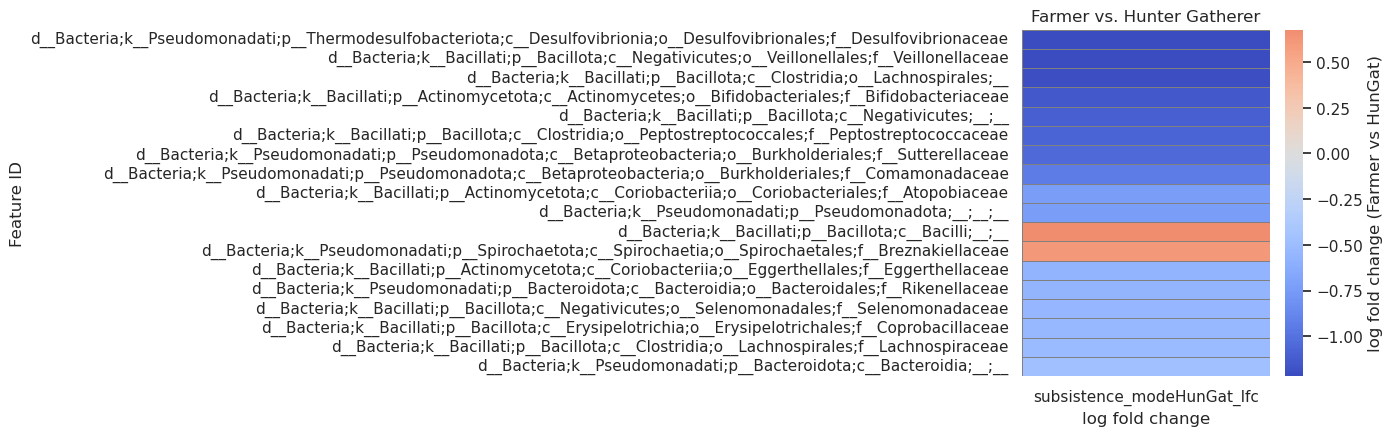

In [6]:
# --- 1. export ANCOM BC differentials to .tsv --- 

!qiime tools export \
    --input-path $data_dir/ancombc_FarmHun_differentials.qza \
    --output-path exported_ancombc_FarmHun

# --- 2. Load and merge the ANCOM-BC outputs ---

# Path to your exported ANCOM-BC results
base = "exported_ancombc_FarmHun"

# Load LFCs and p-values (adjust sep= if needed)
lfc = pd.read_csv(f"{base}/lfc_slice.csv", index_col=0)
pval = pd.read_csv(f"{base}/p_val_slice.csv", index_col=0)

print("LFC columns:", lfc.columns)
print("p-value columns:", pval.columns)

# --- 3. Merge into single DataFrame ---

df = lfc.join(pval, lsuffix="_lfc", rsuffix="_p")
df.head()

# --- 4. Filter to significant features only ---

lfc_col = "subsistence_modeHunGat_lfc"
pval_col = "subsistence_modeHunGat_p"

alpha = 0.05   # significance threshold

sig = df[df[pval_col] < alpha].copy()

print("Significant features:", sig.shape[0])
sig.head()

# --- 5. Sort values (optional) ---

lfc_col = "subsistence_modeHunGat_lfc"

# sort features by LFC (absolute value: strongest changes on top)
sig_sorted = sig.reindex(sig[lfc_col].abs().sort_values(ascending=False).index)

# optionally keep only top N (e.g. 50) for plotting
topN = 50
sig_plot = sig_sorted.head(topN)

# --- 6. Build Matrix for Heat Map ---

heat_data_FarmHun = sig_plot[[lfc_col]]
heat_data_FarmHun.head()

# --- 7. Generate HeatMap ---

sns.set(style="white")

plt.figure(figsize=(4, max(4, 0.25 * heat_data_FarmHun.shape[0])))  # height scales with number of features

ax = sns.heatmap(
    heat_data_FarmHun,
    cmap="PRGn",                      
    center=0,                           
    cbar_kws={"label": "log fold change (Farmer vs HunGat)"},
    linewidths=0.5,
    linecolor="grey"
)

ax.set_xlabel("log fold change")
ax.set_ylabel("Feature ID")
ax.set_title("Farmer vs. Hunter Gatherer")

plt.show()

## 2.5 Western - Fisher

In [6]:
! qiime feature-table filter-samples \
    --i-table $data_dir/table_abund_l6.qza \
    --m-metadata-file $data_dir/updog_metadata.tsv \
    --p-where "[subsistence_mode]='Fisher' or [subsistence_mode]='Western'" \
    --o-filtered-table $data_dir/table_abund_WestFish_l6.qza

/opt/conda/lib/python3.10/site-packages/unifrac/__init__.py:9: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
Saved FeatureTable[Frequency] to: /home/jovyan/Group_Project/UpDoG/table_abund_WestFish_l6.qza


In [9]:
# Run ANCOM-BC
! qiime composition ancombc \
    --i-table $data_dir/table_abund_WestFish_l6.qza \
    --m-metadata-file $data_dir/updog_metadata.tsv \
    --p-formula subsistence_mode \
    --p-reference-levels  "subsistence_mode::Western"\ #had to add this parameter so reference level wouldn't be randomly subsampled
    --o-differentials $data_dir/ancombc_WestFish_differentials.qza

# Generate a barplot of differentially abundant taxa between environments
! qiime composition da-barplot \
    --i-data $data_dir/ancombc_WestFish_differentials.qza \
    --o-visualization $data_dir/ancombc_results/ancombc_WestFish_da_barplot.qzv

# Generate a table of these same values for all taxa
! qiime composition tabulate \
    --i-data $data_dir/ancombc_WestFish_differentials.qza \
    --o-visualization $data_dir/ancombc_results/ancombc_WestFish_results.qzv

/opt/conda/lib/python3.10/site-packages/unifrac/__init__.py:9: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
Saved FeatureData[DifferentialAbundance] to: /home/jovyan/Group_Project/UpDoG/ancombc_WestFish_differentials.qza


In [ ]:
Visualization.load(f"{data_dir}/ancombc_results/ancombc_WestFish_da_barplot.qzv")

In [ ]:
Visualization.load(f"{data_dir}/ancombc_results/ancombc_WestFish_results.qzv")

### 2.5.1 Generate HeatMap WestFish

/opt/conda/lib/python3.10/site-packages/unifrac/__init__.py:9: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
Exported /home/jovyan/Group_Project/UpDoG/ancombc_WestFish_differentials.qza as DataLoafPackageDirFmt to directory exported_ancombc_WestFish
LFC columns: Index(['(Intercept)', 'subsistence_modeFisher'], dtype='object')
p-value columns: Index(['(Intercept)', 'subsistence_modeFisher'], dtype='object')
Significant features: 43


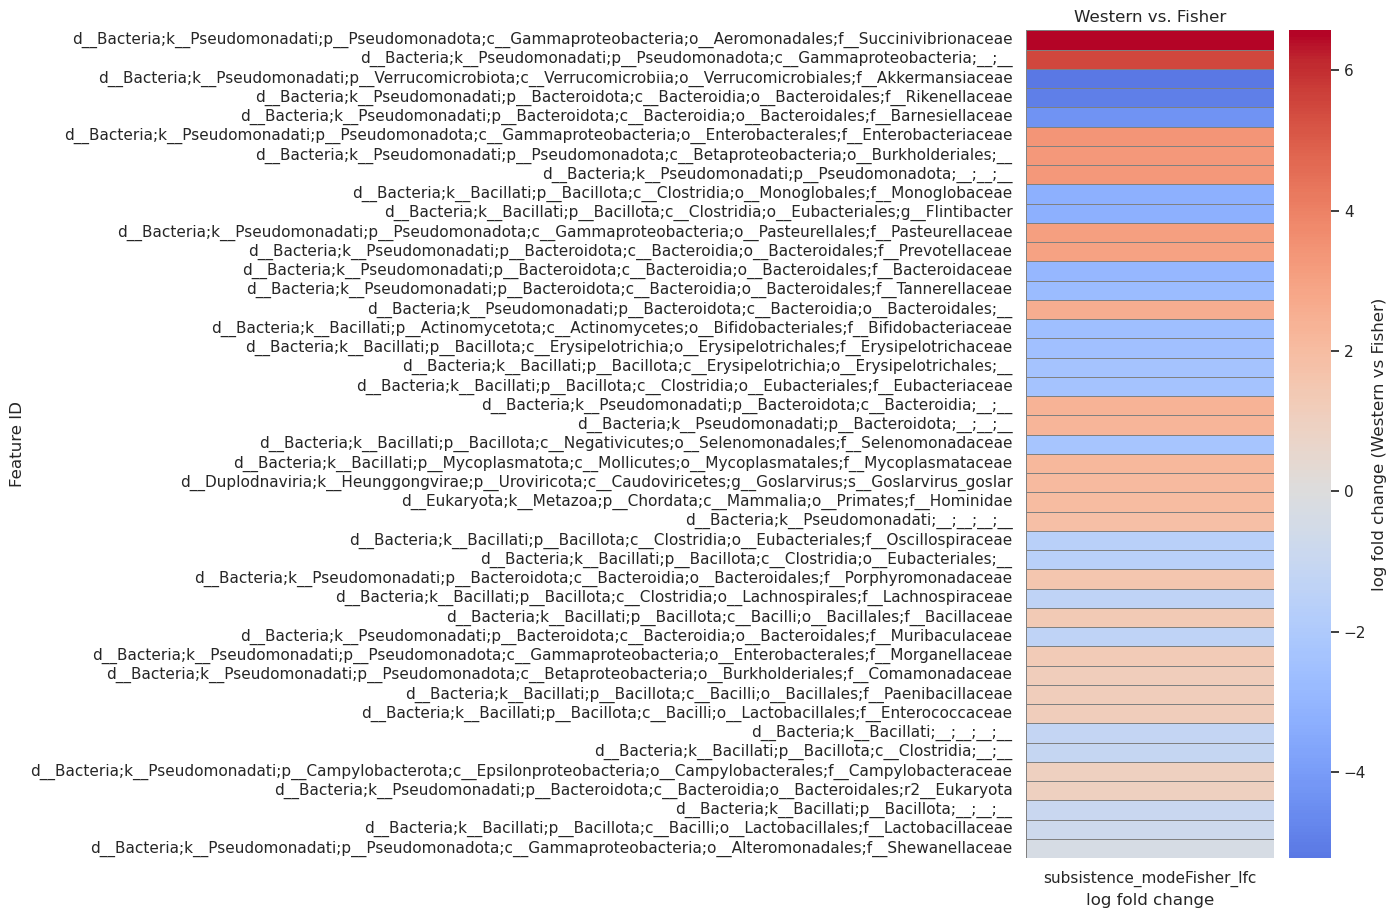

In [12]:
# --- 1. export ANCOM BC differentials to .tsv --- 

!qiime tools export \
    --input-path $data_dir/ancombc_WestFish_differentials.qza \
    --output-path exported_ancombc_WestFish

# --- 2. Load and merge the ANCOM-BC outputs ---

# Path to your exported ANCOM-BC results
base = "exported_ancombc_WestFish"

# Load LFCs and p-values (adjust sep= if needed)
lfc = pd.read_csv(f"{base}/lfc_slice.csv", index_col=0)
pval = pd.read_csv(f"{base}/p_val_slice.csv", index_col=0)

print("LFC columns:", lfc.columns)
print("p-value columns:", pval.columns)

# --- 3. Merge into single DataFrame ---

df = lfc.join(pval, lsuffix="_lfc", rsuffix="_p")
df.head()

# --- 4. Filter to significant features only ---

lfc_col = "subsistence_modeFisher_lfc"
pval_col = "subsistence_modeFisher_p"

alpha = 0.05   # significance threshold

sig = df[df[pval_col] < alpha].copy()

print("Significant features:", sig.shape[0])
sig.head()

# --- 5. Sort values (optional) ---

lfc_col = "subsistence_modeFisher_lfc"

# sort features by LFC (absolute value: strongest changes on top)
sig_sorted = sig.reindex(sig[lfc_col].abs().sort_values(ascending=False).index)

# optionally keep only top N (e.g. 50) for plotting
topN = 50
sig_plot = sig_sorted.head(topN)

# --- 6. Build Matrix for Heat Map ---

heat_data_WestFish = sig_plot[[lfc_col]]
heat_data_WestFish.head()

# --- 7. Generate HeatMap ---

sns.set(style="white")

plt.figure(figsize=(4, max(4, 0.25 * heat_data_WestFish.shape[0])))  # height scales with number of features

ax = sns.heatmap(
    heat_data_WestFish,
    cmap="PRGn",                      
    center=0,                         
    cbar_kws={"label": "log fold change (Western vs Fisher)"},
    linewidths=0.5,
    linecolor="grey"
)

ax.set_xlabel("log fold change")
ax.set_ylabel("Feature ID")
ax.set_title("Western vs. Fisher")

plt.show()

## 2.6 Western - HunGat

In [5]:
! qiime feature-table filter-samples \
    --i-table $data_dir/table_abund_l6.qza \
    --m-metadata-file $data_dir/updog_metadata.tsv \
    --p-where "[subsistence_mode]='Western' or [subsistence_mode]='HunGat'" \
    --o-filtered-table $data_dir/table_abund_WestHun_l6.qza

/opt/conda/lib/python3.10/site-packages/unifrac/__init__.py:9: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
Saved FeatureTable[Frequency] to: /home/jovyan/Group_Project/UpDoG/table_abund_WestHun_l6.qza


In [11]:
# Run ANCOM-BC
! qiime composition ancombc \
    --i-table $data_dir/table_abund_WestHun_l6.qza \
    --m-metadata-file $data_dir/updog_metadata.tsv \
    --p-formula subsistence_mode \
    --p-reference-levels  "subsistence_mode::Western"\
    --o-differentials $data_dir/ancombc_WestHun_differentials.qza

# Generate a barplot of differentially abundant taxa between environments
! qiime composition da-barplot \
    --i-data $data_dir/ancombc_WestHun_differentials.qza \
    --o-visualization $data_dir/ancombc_results/ancombc_WestHun_da_barplot.qzv

# Generate a table of these same values for all taxa
! qiime composition tabulate \
    --i-data $data_dir/ancombc_WestHun_differentials.qza \
    --o-visualization $data_dir/ancombc_results/ancombc_WestHun_results.qzv

/opt/conda/lib/python3.10/site-packages/unifrac/__init__.py:9: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
Saved FeatureData[DifferentialAbundance] to: /home/jovyan/Group_Project/UpDoG/ancombc_WestHun_differentials.qza
/opt/conda/lib/python3.10/site-packages/unifrac/__init__.py:9: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
Saved Visualization to: /home/jovyan/Group_Project/UpDoG/ancombc_WestHun_da_barplot.qzv
/opt/conda/lib/python3.10/site-packages/unifrac/__init__.py:9: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.i

In [ ]:
Visualization.load(f"{data_dir}/ancombc_results/ancombc_WestHun_da_barplot.qzv")

In [ ]:
Visualization.load(f"{data_dir}/ancombc_results/ancombc_WestHun_results.qzv")

### 2.5.1 Generate HeatMap WestHun

/opt/conda/lib/python3.10/site-packages/unifrac/__init__.py:9: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
Exported /home/jovyan/Group_Project/UpDoG/ancombc_WestHun_differentials.qza as DataLoafPackageDirFmt to directory exported_ancombc_WestHun
LFC columns: Index(['(Intercept)', 'subsistence_modeHunGat'], dtype='object')
p-value columns: Index(['(Intercept)', 'subsistence_modeHunGat'], dtype='object')
Significant features: 52


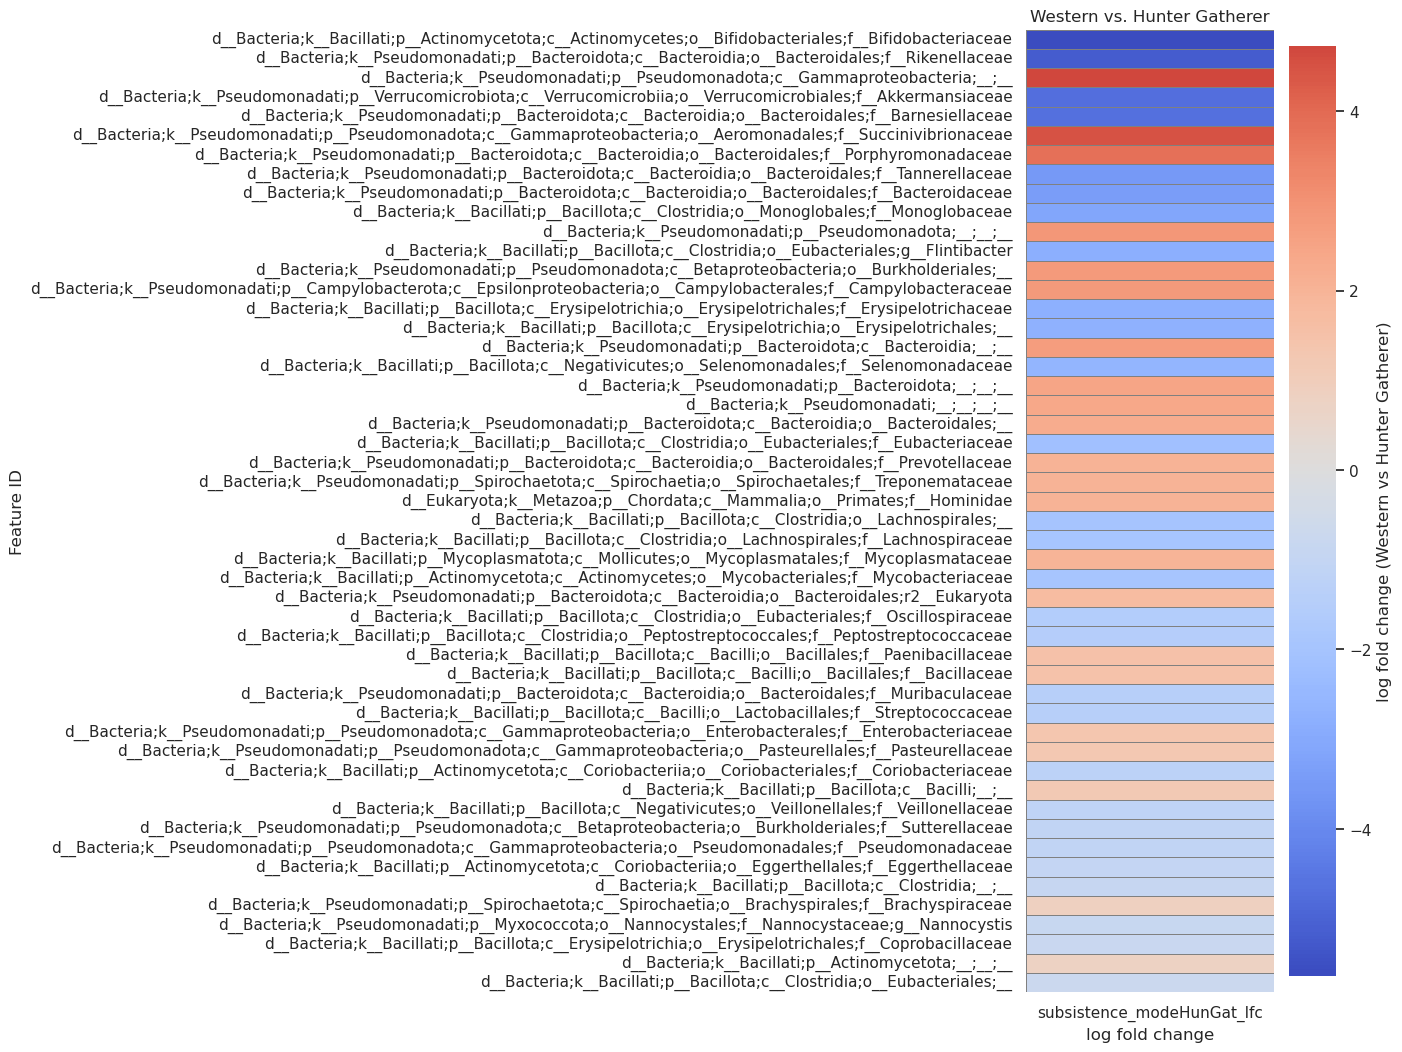

In [13]:
# --- 1. export ANCOM BC differentials to .tsv --- 

!qiime tools export \
    --input-path $data_dir/ancombc_WestHun_differentials.qza \
    --output-path exported_ancombc_WestHun

# --- 2. Load and merge the ANCOM-BC outputs ---

# Path to your exported ANCOM-BC results
base = "exported_ancombc_WestHun"

# Load LFCs and p-values (adjust sep= if needed)
lfc = pd.read_csv(f"{base}/lfc_slice.csv", index_col=0)
pval = pd.read_csv(f"{base}/p_val_slice.csv", index_col=0)

print("LFC columns:", lfc.columns)
print("p-value columns:", pval.columns)

# --- 3. Merge into single DataFrame ---

df = lfc.join(pval, lsuffix="_lfc", rsuffix="_p")
df.head()

# --- 4. Filter to significant features only ---

lfc_col = "subsistence_modeHunGat_lfc"
pval_col = "subsistence_modeHunGat_p"

alpha = 0.05   # significance threshold

sig = df[df[pval_col] < alpha].copy()

print("Significant features:", sig.shape[0])
sig.head()

# --- 5. Sort values (optional) ---

lfc_col = "subsistence_modeHunGat_lfc"

# sort features by LFC (absolute value: strongest changes on top)
sig_sorted = sig.reindex(sig[lfc_col].abs().sort_values(ascending=False).index)

# optionally keep only top N (e.g. 50) for plotting
topN = 50
sig_plot = sig_sorted.head(topN)

# --- 6. Build Matrix for Heat Map ---

heat_data_WestHun = sig_plot[[lfc_col]]
heat_data_WestHun.head()

# --- 7. Generate HeatMap ---

sns.set(style="white")

plt.figure(figsize=(4, max(4, 0.25 * heat_data_WestHun.shape[0])))  # height scales with number of features

ax = sns.heatmap(
    heat_data_WestHun,
    cmap="PRGn",                     
    center=0,                            
    cbar_kws={"label": "log fold change (Western vs Hunter Gatherer)"},
    linewidths=0.5,
    linecolor="grey"
)

ax.set_xlabel("log fold change")
ax.set_ylabel("Feature ID")
ax.set_title("Western vs. Hunter Gatherer")

plt.show()

## 2.7 Fisher - HunGat

In [12]:
! qiime feature-table filter-samples \
    --i-table $data_dir/table_abund_l6.qza \
    --m-metadata-file $data_dir/updog_metadata.tsv \
    --p-where "[subsistence_mode]='Fisher' or [subsistence_mode]='HunGat'" \
    --o-filtered-table $data_dir/table_abund_FishHun_l6.qza

/opt/conda/lib/python3.10/site-packages/unifrac/__init__.py:9: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
Saved FeatureTable[Frequency] to: /home/jovyan/Group_Project/UpDoG/table_abund_FishHun_l6.qza


In [13]:
# Run ANCOM-BC
! qiime composition ancombc \
    --i-table $data_dir/table_abund_FishHun_l6.qza \
    --m-metadata-file $data_dir/updog_metadata.tsv \
    --p-formula subsistence_mode \
    --p-reference-levels  "subsistence_mode::Fisher"\
    --o-differentials $data_dir/ancombc_FishHun_differentials.qza

# Generate a barplot of differentially abundant taxa between environments
! qiime composition da-barplot \
    --i-data $data_dir/ancombc_FishHun_differentials.qza \
    --o-visualization $data_dir/ancombc_FishHun_da_barplot.qzv

# Generate a table of these same values for all taxa
! qiime composition tabulate \
    --i-data $data_dir/ancombc_FishHun_differentials.qza \
    --o-visualization $data_dir/ancombc_FishHun_results.qzv

/opt/conda/lib/python3.10/site-packages/unifrac/__init__.py:9: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
Saved FeatureData[DifferentialAbundance] to: /home/jovyan/Group_Project/UpDoG/ancombc_FishHun_differentials.qza
/opt/conda/lib/python3.10/site-packages/unifrac/__init__.py:9: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
Saved Visualization to: /home/jovyan/Group_Project/UpDoG/ancombc_FishHun_da_barplot.qzv
/opt/conda/lib/python3.10/site-packages/unifrac/__init__.py:9: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.i

In [ ]:
Visualization.load(f"{data_dir}/ancombc_FishHun_da_barplot.qzv")

In [ ]:
Visualization.load(f"{data_dir}/ancombc_FishHun_results.qzv")

### 2.5.1 Generate HeatMap FishHun

/opt/conda/lib/python3.10/site-packages/unifrac/__init__.py:9: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
Exported /home/jovyan/Group_Project/UpDoG/ancombc_FishHun_differentials.qza as DataLoafPackageDirFmt to directory exported_ancombc_FishHun
LFC columns: Index(['(Intercept)', 'subsistence_modeHunGat'], dtype='object')
p-value columns: Index(['(Intercept)', 'subsistence_modeHunGat'], dtype='object')
Significant features: 34


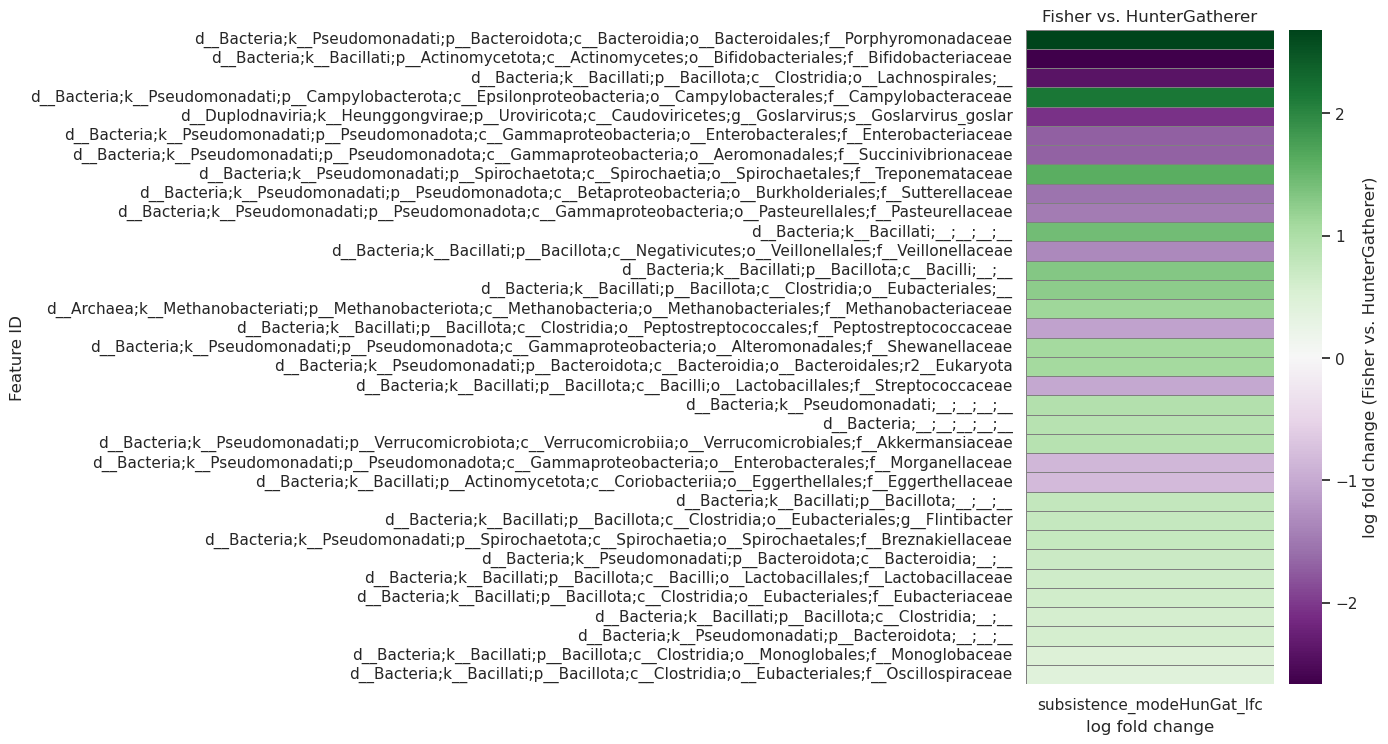

In [95]:
# --- 1. export ANCOM BC differentials to .tsv --- 

!qiime tools export \
    --input-path $data_dir/ancombc_FishHun_differentials.qza \
    --output-path exported_ancombc_FishHun

# --- 2. Load and merge the ANCOM-BC outputs ---

# Path to your exported ANCOM-BC results
base = "exported_ancombc_FishHun"

# Load LFCs and p-values (adjust sep= if needed)
lfc = pd.read_csv(f"{base}/lfc_slice.csv", index_col=0)
pval = pd.read_csv(f"{base}/p_val_slice.csv", index_col=0)

print("LFC columns:", lfc.columns)
print("p-value columns:", pval.columns)

# --- 3. Merge into single DataFrame ---

df = lfc.join(pval, lsuffix="_lfc", rsuffix="_p")
df.head()

# --- 4. Filter to significant features only ---

lfc_col = "subsistence_modeHunGat_lfc"
pval_col = "subsistence_modeHunGat_p"

alpha = 0.05   # significance threshold

sig = df[df[pval_col] < alpha].copy()

print("Significant features:", sig.shape[0])
sig.head()

# --- 5. Sort values (optional) ---

lfc_col = "subsistence_modeHunGat_lfc"

# sort features by LFC (absolute value: strongest changes on top)
sig_sorted = sig.reindex(sig[lfc_col].abs().sort_values(ascending=False).index)

# optionally keep only top N (e.g. 50) for plotting
topN = 50
sig_plot = sig_sorted.head(topN)

# --- 6. Build Matrix for Heat Map ---

heat_data_FishHun = sig_plot[[lfc_col]]
heat_data_FishHun.head()

# --- 7. Generate HeatMap ---

sns.set(style="white")

plt.figure(figsize=(4, max(4, 0.25 * heat_data_FishHun.shape[0])))  # height scales with number of features

ax = sns.heatmap(
    heat_data_FishHun,
    cmap="PRGn",                      # red/blue style colormap
    center=0,                             # 0 is neutral
    cbar_kws={"label": "log fold change (Fisher vs. HunterGatherer)"},
    linewidths=0.5,
    linecolor="grey"
)

ax.set_xlabel("log fold change")
ax.set_ylabel("Feature ID")
ax.set_title("Fisher vs. HunterGatherer")

plt.show()

# 3. Merge all HeatMaps into one

In [79]:
# --- 1. Put each DataFrame into a dictionary

dfs = {
    "Farm_vs_West": heat_data_FarmWest,
    "Farm_vs_Fish": heat_data_FarmFish,
    "Farm_vs_Hun": heat_data_FarmHun,
    "West_vs_Fish": heat_data_WestFish,
    "West_vs_Hun": heat_data_WestHun,
    "Fish_vs_Hun": heat_data_FishHun
}

In [80]:
# --- 2. Rename each LFC column to the contrast name

renamed = {}

for name, df in dfs.items():
    col = df.columns[0]
    renamed[name] = df.rename(columns={col: name})

In [81]:
# --- 3. Merge all of them by ASV ID

from functools import reduce

heatmap_df = reduce(
    lambda left, right: left.join(right, how='outer'),
    renamed.values()
)

In [92]:
# --- 4. Optional: Fill NaN's

heatmap_df = heatmap_df.fillna(0)

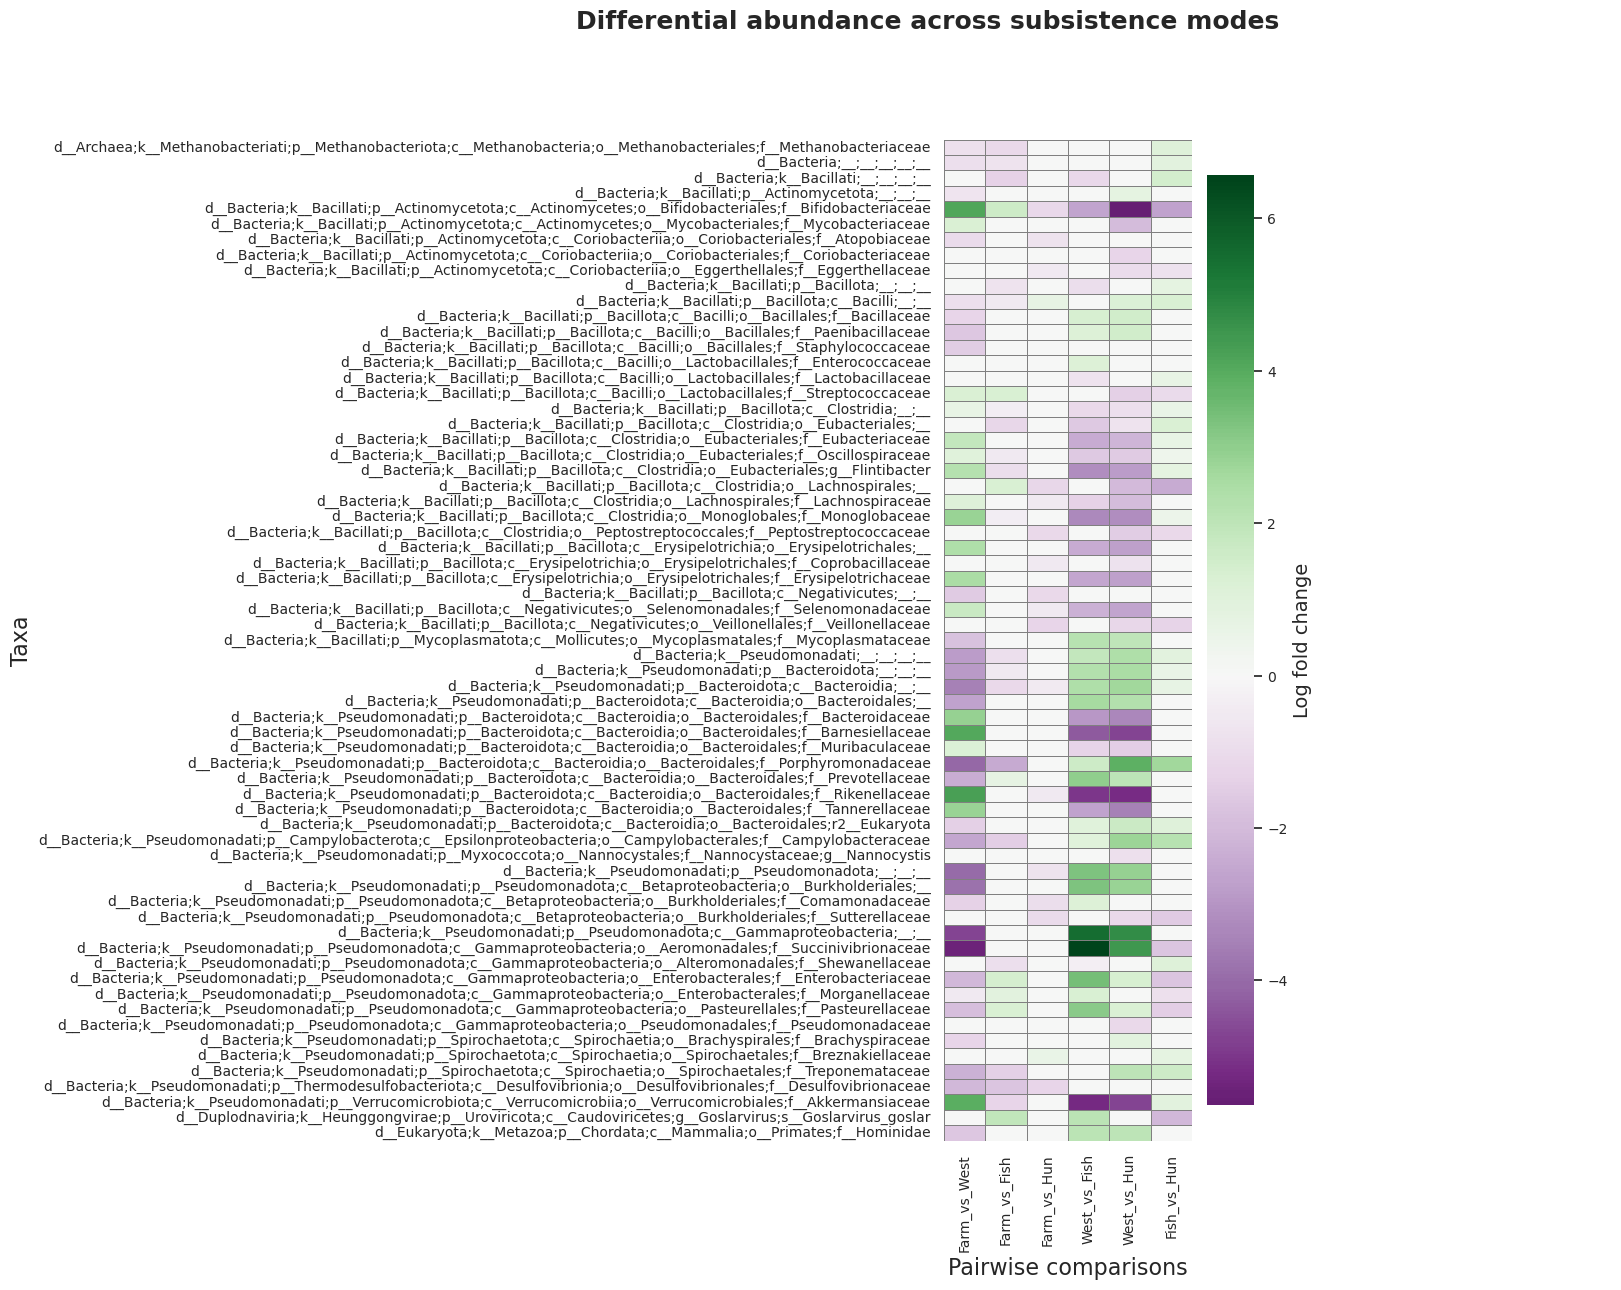

In [94]:
# --- 5. Plot the combined heatmap

plt.figure(figsize=(4, max(4, 0.2 * heatmap_df.shape[0])))

sns.heatmap(
    heatmap_df,
    cmap="PRGn",
    center=0,
    linewidths=0.4,
    linecolor="grey",
    cbar_kws={"label": "Log fold change"},
)
plt.suptitle(
    "Differential abundance across subsistence modes                                      ",
    fontsize=18,         
    fontweight="bold",
)


plt.xlabel(
    "Pairwise comparisons",
    fontsize=16
)
plt.ylabel(
    "Taxa",
    fontsize=16
)
plt.savefig("/$data_dir/differential_abundance_heatmap.pdf", dpi=300, bbox_inches="tight")
#plt.tight_layout()
plt.show()